In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

df_LR_assembly_metadata = pd.read_csv("../../data/TRUST.PBAsm.ZA_106CI_AssemblySummary.csv")
df_LR_assembly_metadata['Lineage'] = df_LR_assembly_metadata['Lineage_Asm'].str.replace('lineage', '')

# this keeps only those with NumContigs = 1 and numContigs_Complete = 1 in df_LR_assembly_metadata, and the lineages (Coll2014 exactly) of the LR and SR sequences must match
df_personal_assemblies = pd.read_csv("../data/personal_assemblies_samples.tsv", sep='\t', header=None, names = ['Sample', 'Assembly', 'PacBio'])
samples_with_assemblies = df_personal_assemblies['Sample'].values

df_trust_patients = pd.read_csv("~/TRUST_data_processing/processed_data/20250904_cleaned_patient_outcomes_data.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
SNP_dist = pd.read_csv("../../data/freebayes_excludeLowConf_SNPs_noLineageMixes_filtered.csv", header=None, names=['Sample1', 'Sample2', 'Dist'])
SNP_dist['Sample1'] = SNP_dist['Sample1'].str.split('.').str[0]
SNP_dist['Sample2'] = SNP_dist['Sample2'].str.split('.').str[0]

SNP_dist = SNP_dist.merge(df_trust_patients[['SampleID', 'pid', 'Coll2014']].rename(columns={'SampleID': 'Sample1', 'pid': 'pid1', 'Coll2014': 'Coll2014_1'}), how='left')
SNP_dist = SNP_dist.merge(df_trust_patients[['SampleID', 'pid', 'Coll2014']].rename(columns={'SampleID': 'Sample2', 'pid': 'pid2', 'Coll2014': 'Coll2014_2'}), how='left')

F2_thresh = 0.03

unmixed_lineage_samples = df_trust_patients.query("F2 <= @F2_thresh").SampleID.unique()

from utils import *

In [ ]:
python -m ipykernel install --name bayesian_modeling --display-name "Bayesenv"

In [250]:
samples_lst = os.listdir(H37Rv_ref_dir)
print(len(samples_lst))

samples_lst.index('MFS-830')

774


696

In [2]:
df_trust_patients.query("SampleID in @samples_with_assemblies").Coll2014.unique()

array(['4.1.1.1', '2.2.1.1', '2.2.1', '4.8', '4.4.1.1', '4.1.2.1',
       '4.3.2.1', '4.3.3', '4.1.1.3', '3.1.1', '3', '4.3.2.1,2.2.1.1',
       '4.1.2'], dtype=object)

In [3]:
df_trust_patients.query("SampleID in @samples_with_assemblies & Coll2014=='3.1.1'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
683,T0013,S0013-01,MFS-5,MFS-5_lib45535,NaN,NaN,1.0,344.87,1.0,0.9892,...,42.137,3.9986,364.35,16.463,1B,0.0,21.112646,24.960957,361,NaN


In [4]:
set(df_trust_patients.dropna(subset='Coll2014').query("~Coll2014.str.contains(',')").Coll2014) - set(df_trust_patients.query("SampleID in @samples_with_assemblies").Coll2014)

{'1.1.2',
 '4.1',
 '4.1.1.2',
 '4.2.2',
 '4.3.2',
 '4.3.4.1',
 '4.3.4.2.1',
 '4.7',
 '4.9'}

In [2]:
def get_samples_to_align_to_personal_ref_genome(lineage_string):
    
    lineage_lst = lineage_string.split(',')
    
    samples_needed = df_trust_patients.query("Coll2014 in @lineage_lst & SampleID in @unmixed_lineage_samples & SampleID in @samples_with_assemblies").SampleID.unique()
    
    # take the first one as the assembly. When running this on all samples, remove the requirement that SampleID be in samples_with_assemblies when getting samples_needed
    assembly_sample = np.sort(samples_needed)[0]
    
    # then remove assembly_sample from samples_needed
    samples_needed = list(set(samples_needed) - set([assembly_sample]))
    
    for name in samples_needed:
        if not os.path.isfile(f"{H37Rv_ref_dir}/{name}/{name}/kraken/{name}.R1.kraken.filtered.fastq.gz"):
            print(name)
            
    if len(lineage_lst) == 1:
        saveName = f"SR_samples_align_{lineage_lst[0]}_{assembly_sample}_ASM.txt"
    else:
        saveName = f"SR_samples_align_{','.join(lineage_lst)}_{assembly_sample}_ASM.txt"
      
    if len(samples_needed) > 0:
        print(f"{len(samples_needed)} will be aligned to the {assembly_sample} assembly ({lineage_string})")
        pd.Series(samples_needed).to_csv(saveName, sep='\t', header=None, index=False)

In [3]:
# combine_lineage_dict = {'2.2.1,2.2.1.1': False,
#                         '3,3.1.1': False,
#                         '4.1.1.1,4.1.1.3,4.1.2': False
#                        }

# only combine these because there's only 1 of each, so there's no way to know if using another sample works, unless we broaden the search a little bit
combine_lineage_dict = {'3,3.1.1': False}

for lineage in df_trust_patients.dropna(subset='Coll2014').query("SampleID in @samples_with_assemblies & ~Coll2014.str.contains(',')").Coll2014.unique():
    
    combo_lineage = False
    
    for lineage_string in combine_lineage_dict.keys():
        if len(set(lineage_string.split(',')).intersection([lineage])) > 0:
            combo_lineage = True
            break
        
    if combo_lineage:
        if not combine_lineage_dict[lineage_string]:
            get_samples_to_align_to_personal_ref_genome(lineage_string)
            combine_lineage_dict[lineage_string] = True
            # print(f"{lineage} is in a combo")
    else:
        get_samples_to_align_to_personal_ref_genome(lineage)
        # print(lineage)

9 will be aligned to the MFS-136 assembly (4.1.1.1)
51 will be aligned to the MFS-1 assembly (2.2.1.1)
17 will be aligned to the MFS-16 assembly (2.2.1)
4 will be aligned to the MFS-104 assembly (4.8)
4 will be aligned to the MFS-150 assembly (4.4.1.1)
6 will be aligned to the MFS-160 assembly (4.3.2.1)
1 will be aligned to the MFS-56 assembly (4.1.1.3)
1 will be aligned to the MFS-135 assembly (3,3.1.1)
1 will be aligned to the MFS-308 assembly (4.1.2)


In [4]:
def compare_variants_two_personal_ref_genomes(assembly_sample, variants_personal_fName, variants_other_personal_fName):

    assert os.path.isfile(variants_personal_fName)
    assert os.path.isfile(variants_other_personal_fName)
        
    # if this fails, it's empty
    try:
        df_variants_personal = pd.read_csv(variants_personal_fName, sep='\t', header='infer')#, usecols=[0, 1, 2])
        # df_variants_personal.columns = ['CHROM', 'BEG', 'END']
        df_variants_personal[['BEG', 'END']] = df_variants_personal[['BEG', 'END']].astype(int)
    except:
        df_variants_personal = pd.DataFrame(columns = ['CHROM', 'BEG', 'END'], index=[0])
        
    try:
        df_variants_other_personal = pd.read_csv(variants_other_personal_fName, sep='\t', header=None, usecols=[0, 1, 2, 3])
        df_variants_other_personal.columns = ['ASM_CHROM', 'ASM_BEG', 'ASM_END', 'SplitCol']
        df_variants_other_personal[['CHROM', 'BEG', 'END']] = df_variants_other_personal['SplitCol'].str.rsplit('_', n=2, expand=True)
        df_variants_other_personal[['ASM_BEG', 'ASM_END']] = df_variants_other_personal[['ASM_BEG', 'ASM_END']].astype(int)

        # to merge with the TSV of variant information. This file is just the BED file, so it doesn't have variant information
        df_variants_other_personal['POS'] = df_variants_other_personal['BEG'].astype(int) + 1 
    except:
        df_variants_other_personal = pd.DataFrame(columns = ['ASM_CHROM', 'ASM_BEG', 'ASM_END', 'POS'], index=[0])

    # get the variant information
    other_ASM_variants_fName = os.path.join(os.path.dirname(variants_other_personal_fName), f"{sample}.excludeLowConf.tsv")
    df_other_ASM_variants = pd.read_csv(other_ASM_variants_fName, sep='\t')
    df_other_ASM_variants['AF'] = df_other_ASM_variants['AO'] / df_other_ASM_variants['DP']

    df_variants_other_personal = df_variants_other_personal.merge(df_other_ASM_variants[['POS', 'REF', 'ALT', 'AF']], on='POS')

    # remove variants at high frequency. These may not be picked up because slight differences can cause one variant to be picked up at AF = 0.04 vs. AF = 0.06
    # then it'll come up as a false negative or positive because of the threshold we used, requiring that a low frequency variant be ≥ 0.05
    df_variants_other_personal = df_variants_other_personal.query("AF <= 0.95")

    del_cols = []

    # so that after merging, we don't get multiples. These are not always going to match
    for col in ['CHROM', 'BEG', 'END', 'POS', 'REF', 'ALT', 'AF']:
        if col in df_variants_other_personal.columns:
            del df_variants_other_personal[col]

    df_variants_comparison = df_variants_personal.merge(df_variants_other_personal, 
                                                        left_on=['CHROM', 'BEG', 'END'], 
                                                        right_on=['ASM_CHROM', 'ASM_BEG', 'ASM_END'], 
                                                        how='outer')

    df_variants_comparison['ASM'] = assembly_sample

    # ONLY SNPs
    df_variants_comparison['varLen'] = df_variants_comparison['END'] - df_variants_comparison['BEG']
    df_variants_comparison['ASM_varLen'] = df_variants_comparison['ASM_END'] - df_variants_comparison['ASM_BEG']

    # have to do ~varLen > 1 so that you don't drop cases that are NA. NAs are those found in one BED file but not in another (important for tabulating results!!!)
    df_variants_comparison = df_variants_comparison.loc[~(df_variants_comparison["varLen"] > 1) & ~(df_variants_comparison["ASM_varLen"] > 1)].reset_index(drop=True)

    if len(df_variants_comparison) > 0:

        # found in personal ref genome, but not using the other personal ref genome. Means missed = FN
        df_variants_comparison.loc[(~pd.isnull(df_variants_comparison['BEG'])) & (pd.isnull(df_variants_comparison['ASM_BEG'])), 'Result'] = 'FN'

        # not found in personal ref genome, but found using the other personal ref genome. Means FP
        df_variants_comparison.loc[(pd.isnull(df_variants_comparison['BEG'])) & (~pd.isnull(df_variants_comparison['ASM_BEG'])), 'Result'] = 'FP'

        # found in both. Means correct = TP
        df_variants_comparison.loc[(~pd.isnull(df_variants_comparison['BEG'])) & (~pd.isnull(df_variants_comparison['ASM_BEG'])), 'Result'] = 'TP'

        return df_variants_comparison.dropna(axis=1, how='all')

In [5]:
assembly_fNames = glob.glob("./*ASM.txt")

assembly_fNames

['./SR_samples_align_2.2.1.1_MFS-1_ASM.txt',
 './SR_samples_align_2.2.1_MFS-16_ASM.txt',
 './SR_samples_align_3,3.1.1_MFS-135_ASM.txt',
 './SR_samples_align_4.1.1.1_MFS-136_ASM.txt',
 './SR_samples_align_4.1.1.3_MFS-56_ASM.txt',
 './SR_samples_align_4.1.2_MFS-308_ASM.txt',
 './SR_samples_align_4.3.2.1_MFS-160_ASM.txt',
 './SR_samples_align_4.4.1.1_MFS-150_ASM.txt',
 './SR_samples_align_4.8_MFS-104_ASM.txt']

In [8]:
df_variants_comparison_all_samples = []
finished_samples = []

for fName in assembly_fNames:

    assembly_sample = fName.split('_')[-2]

    samples_needed = pd.read_csv(fName, sep='\t', header=None)[0].values
    
    df_variants_comparison_combined = []
    
    for sample in samples_needed:

        # variants_personal_fName = f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed"
        variants_personal_fName = f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.excludeLowConf.bed"

        # variants_other_personal_fName = f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed"
        variants_other_personal_fName = f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/lowAF_variants.excludeLowConf.{sample}.bed"
        # variants_other_personal_fName = f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/lowAF_variants.{sample}.bed"

        if os.path.isfile(variants_personal_fName) and os.path.isfile(variants_other_personal_fName):

            df_variants_comparison = compare_variants_two_personal_ref_genomes(assembly_sample, variants_personal_fName, variants_other_personal_fName)

            if df_variants_comparison is not None:
                df_variants_comparison['SampleID'] = sample

                df_variants_comparison_combined.append(df_variants_comparison)

            finished_samples.append(sample)

    if len(finished_samples) > 0:

        if len(df_variants_comparison_combined) > 0:
            # Result = 'na' occurs for empty dataframes (no variants found), so remove them
            df_variants_comparison_combined = pd.concat(df_variants_comparison_combined).query("Result != 'na'")

            # add SNP distances
            df_variants_comparison_combined = df_variants_comparison_combined.merge(SNP_dist.query("Sample1==@assembly_sample")[['Sample2', 'Dist']].drop_duplicates().rename(columns={'Sample2': 'SampleID'}), on='SampleID')
        else:
            print(f"No low-frequency SNPs")
            
        df_variants_comparison_all_samples.append(df_variants_comparison_combined)
    else:
        continue

print(f"{len(finished_samples)} samples")
    
df_variants_comparison_all_samples = pd.concat(df_variants_comparison_all_samples)

94 samples


In [9]:
df_variants_comparison_all_samples.Result.value_counts()

Result
TP    239
FP     34
FN      3
Name: count, dtype: int64

In [10]:
set(os.listdir(personal_ref_dir)).intersection(unmixed_lineage_samples) - set(finished_samples)

{'MFS-1',
 'MFS-104',
 'MFS-106',
 'MFS-135',
 'MFS-136',
 'MFS-150',
 'MFS-16',
 'MFS-160',
 'MFS-308',
 'MFS-44',
 'MFS-56'}

In [11]:
samples_with_FP = df_variants_comparison_all_samples.query("Result=='FP'").SampleID.unique()
len(samples_with_FP)

12

In [36]:
samples_with_FP

array(['MFS-5', 'MFS-328', 'MFS-6', 'MFS-327', 'MFS-25', 'MFS-26',
       'MFS-314', 'MFS-181', 'MFS-61', 'MFS-60', 'MFS-310', 'MFS-311'],
      dtype=object)

In [12]:
df_trust_patients.query("SampleID in @finished_samples").Coll2014.value_counts()

Coll2014
2.2.1.1    51
2.2.1      17
4.1.1.1     9
4.3.2.1     6
4.8         4
4.4.1.1     4
4.1.1.3     1
3.1.1       1
4.1.2       1
Name: count, dtype: int64

In [13]:
df_trust_patients.query("SampleID in @samples_with_FP & SampleID in @finished_samples")[['pid', 'SampleID', 'Original_ID', 'Coll2014', 'Freschi2020']].sort_values(['Coll2014', 'SampleID'])

,pid,SampleID,Original_ID,Coll2014,Freschi2020
683,T0013,MFS-5,S0013-01,3.1.1,3.1.1.i1
585,T0045,MFS-25,S0045-01,4.3.2.1,4.2.1.2.1.1.i1
586,T0045,MFS-26,S0045-07,4.3.2.1,4.2.1.2.1.1.i1
736,T0305,MFS-314,S0305-08,4.3.2.1,4.2.1.2.1.1.i1
738,T0285,MFS-327,S0285-01,4.3.2.1,4.2.1.2.1.1.i1
739,T0285,MFS-328,S0285-08,4.3.2.1,4.2.1.2.1.1.i1
684,T0013,MFS-6,S0013-09,4.3.2.1,4.2.1.2.1.1.i1
607,T0262,MFS-181,S0262-02,4.4.1.1,4.2.1.2.2.1.1
560,T0123,MFS-60,S0123-01,4.4.1.1,4.2.1.2.2.1.1
561,T0123,MFS-61,S0123-07,4.4.1.1,4.2.1.2.2.1.1


In [66]:
df_trust_patients.query("SampleID=='MFS-160'")[['pid', 'SampleID', 'Coll2014', 'Freschi2020']]

,pid,SampleID,Coll2014,Freschi2020
671,T0247,MFS-160,4.3.2.1,4.2.1.2.1.1.i1


In [63]:
df_variants_comparison_all_samples.query("SampleID=='MFS-6'").ASM.values[0]

'MFS-160'

In [32]:
# df_variants_comparison_all_samples.query("Result=='FP'").sort_values('SampleID').dropna(axis=1, how='all').groupby('SampleID').count()

In [31]:
df_FP_lineage_comparison = df_variants_comparison_all_samples.query("SampleID in @samples_with_FP")[['SampleID', 'ASM']].drop_duplicates()

df_FP_lineage_comparison = df_FP_lineage_comparison.merge(df_trust_patients[['SampleID', 'Coll2014', 'Freschi2020']])

df_FP_lineage_comparison = df_FP_lineage_comparison.merge(df_trust_patients[['SampleID', 'Coll2014', 'Freschi2020']].rename(columns={'SampleID': 'ASM', 'Coll2014': 'ASM_Coll2014', 'Freschi2020': 'ASM_Freschi2020'}))



In [35]:
df_FP_lineage_comparison.query("SampleID=='MFS-26'")

,SampleID,ASM,Coll2014,Freschi2020,ASM_Coll2014,ASM_Freschi2020
5,MFS-26,MFS-160,4.3.2.1,4.2.1.2.1.1.i1,4.3.2.1,4.2.1.2.1.1.i1


In [72]:
df_FP_lineage_comparison.query("Freschi2020 != ASM_Freschi2020")

,SampleID,ASM,Coll2014,Freschi2020,ASM_Coll2014,ASM_Freschi2020
0,MFS-5,MFS-135,3.1.1,3.1.1.i1,3,3.1.1


In [73]:
df_FP_lineage_comparison.query("Coll2014 != ASM_Coll2014")

,SampleID,ASM,Coll2014,Freschi2020,ASM_Coll2014,ASM_Freschi2020
0,MFS-5,MFS-135,3.1.1,3.1.1.i1,3,3.1.1


In [47]:
df_variants_comparison_all_samples.query("Result=='FP' & SampleID != 'MFS-5'")['SampleID'].value_counts()

SampleID
MFS-327    3
MFS-26     3
MFS-25     3
MFS-328    3
MFS-314    3
MFS-6      3
MFS-60     2
MFS-61     2
MFS-181    2
MFS-310    2
MFS-311    2
Name: count, dtype: int64

In [38]:
sample = 'MFS-60'
assembly_sample = df_variants_comparison_all_samples.query("SampleID==@sample").ASM.values[0]

# variants_personal_fName = f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed"
variants_personal_fName = f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.excludeLowConf.bed"

# variants_other_personal_fName = f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/lowAF_variants.H37Rv.excludeLowConf.bed"
variants_other_personal_fName = f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/lowAF_variants.excludeLowConf.{sample}.bed"
# variants_other_personal_fName = f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/lowAF_variants.{sample}.bed"

df_variants_comparison = compare_variants_two_personal_ref_genomes(assembly_sample, variants_personal_fName, variants_other_personal_fName)

In [39]:
df_variants_comparison

,ASM_CHROM,ASM_BEG,ASM_END,SplitCol,ASM,ASM_varLen,Result
0,S0123-01_contig_1_pilon,2628235,2628236,S0242-01_contig_1_pilon_2635040_2635041,MFS-150,1,FP
1,S0123-01_contig_1_pilon,3366692,3366693,S0242-01_contig_1_pilon_3373159_3373160,MFS-150,1,FP


In [40]:
df_depth = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/bam/{sample}.properlyPaired.depth.tsv.gz",
                       sep='\t',
                       header=None,
                       compression='gzip',
                       names=['CHROM', 'POS', 'DEPTH']
                      )

depth_min = df_depth['DEPTH'].median() / 2
depth_max = df_depth['DEPTH'].median() * 2

depth_min, depth_max

(116.0, 464.0)

In [21]:
df_trust_patients.query("SampleID in [@sample, @assembly_sample]")[['Original_ID', 'SampleID']]

,Original_ID,SampleID
586,S0045-07,MFS-26
671,S0247-01,MFS-160


In [41]:
df_depth.query("POS in [2635041, 3373160]")

,CHROM,POS,DEPTH
2635040,S0242-01_contig_1_pilon,2635041,230
3373159,S0242-01_contig_1_pilon,3373160,457


In [416]:
df_personal_ASM_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/{sample}.tsv", sep='\t')
df_personal_ASM_variants['AF'] = df_personal_ASM_variants['AO'] / df_personal_ASM_variants['DP']

In [417]:
df_other_ASM_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/personal_ref_genomes/{assembly_sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t')
df_other_ASM_variants['AF'] = df_other_ASM_variants['AO'] / df_other_ASM_variants['DP']

In [419]:
df_other_ASM_variants[['CHROM', 'POS', 'REF', 'ALT', 'AO', 'DP', 'AF']].query("POS in [408359, 408397]")

,CHROM,POS,REF,ALT,AO,DP,AF
123,S0004-01_contig_1_pilon,408397,C,T,79,257,0.307393


In [422]:
df_trust_patients.query("SampleID in [@sample, @assembly_sample]")[['pid', 'SampleID', 'Original_ID', 'Coll2014', 'F2']]

,pid,SampleID,Original_ID,Coll2014,F2
655,T0004,MFS-1,S0004-01,2.2.1.1,0.011212
666,T0031,MFS-16,S0031-01,2.2.1,0.010009


In [457]:
search_samples = df_trust_patients.query("SampleID in @samples_with_assemblies & Coll2014=='2.2.1'")[['pid', 'SampleID']].SampleID.values

In [458]:
df_variants_comparison_all_samples.query("SampleID in @search_samples").Result.value_counts()

Result
TP    52
FP    18
Name: count, dtype: int64

In [459]:
df_variants_comparison_all_samples.query("SampleID in @search_samples").query("Result=='FP'")

,CHROM,BEG,END,POS,REF,ALT,QUAL,DP,RO,AO,...,ASM_CHROM,ASM_BEG,ASM_END,SplitCol,ASM,varLen,ASM_varLen,Result,SampleID,Dist
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0141-01_contig_1_pilon,408415.0,408416.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-70,222
21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0276-01_contig_1_pilon,408358.0,408359.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-321,217
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0265-01_contig_1_pilon,408415.0,408416.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-184,226
51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0007-01_contig_1_pilon,409719.0,409720.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-3,219
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0031-08_contig_1_pilon,408358.0,408359.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-17,222
93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0100-01_contig_1_pilon,408358.0,408359.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-55,223
110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0031-01_contig_1_pilon,408358.0,408359.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-16,222
113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0299-01_contig_1_pilon,408414.0,408415.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-259,195
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0070-01_contig_1_pilon,408358.0,408359.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-41,218
124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S0299-09_contig_1_pilon,408414.0,408415.0,S0004-01_contig_1_pilon_408396_408397,MFS-1,NaN,1.0,FP,MFS-312,195


In [196]:
df_trust_patients.query("SampleID in ['MFS-1', 'MFS-129']")[['pid', 'SampleID', 'Coll2014', 'F2']]

,pid,SampleID,Coll2014,F2
655,T0004,MFS-1,2.2.1.1,0.011212
689,T0220,MFS-129,2.2.1.1,0.009631


In [198]:
SNP_dist.query("Sample1=='MFS-1' & Sample2=='MFS-129'")

,Sample1,Sample2,Dist,pid1,Coll2014_1,pid2,Coll2014_2
33,MFS-1,MFS-129,48,T0004,2.2.1.1,T0220,2.2.1.1


<Axes: xlabel='Dist', ylabel='Prop'>

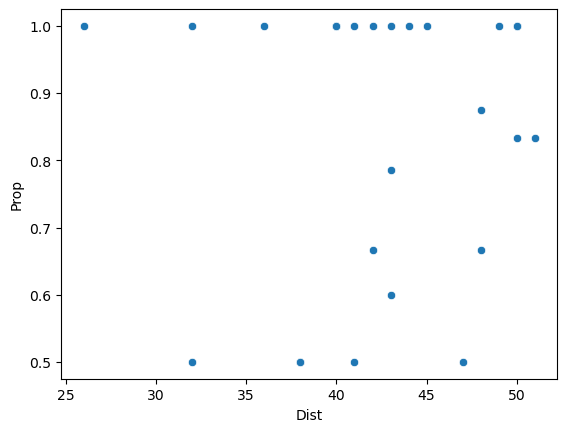

In [81]:
sns.scatterplot(data=df_variants_comparison_summary.query("Result=='TP'"),
                x='Dist',
                y='Prop'
               )

In [66]:
df_variants_comparison_summary.sort_values('SampleID')

,SampleID,Dist,Result,count
0,MFS-110,44,TP,4
1,MFS-113,50,TP,15
2,MFS-116,47,TP,1
3,MFS-116,47,FP,1
4,MFS-120,49,TP,1
5,MFS-121,50,TP,1
6,MFS-122,41,TP,2
7,MFS-130,48,TP,7
8,MFS-130,48,FP,1
10,MFS-132,43,FP,3


In [38]:
Pacbio_updated_table = pd.read_excel("~/TRUST_data_processing/raw_data/PacBio_update2025.xlsx")

Max_LR_metadata = pd.read_csv("~/TRUST_data_processing/raw_data/230902.TRUST.LRandSR.Set1to4.106CI.InputWGS.PATHs.tsv", sep='\t')

In [37]:
Pacbio_updated_table.query("MFS_ID in ['MFS-1', 'MFS-218']")#.fastq_path.values[0]

,MFS_ID,PID,barcode_number,Sequencing_batch,fastq_path
34,MFS-218,NaN,bc2081--bc2081,3,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...


In [42]:
Max_LR_metadata.query("PacBio_FQ_PATH=='/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2081--bc2081.hifi_reads.fastq.gz'").Illumina_PE_FQs_PATH.values[0]

'/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Illumina/220510.ZA.Set1.FQs/Merged_PE_FASTQs_V2/MFS-1_lib45531_R1.fastq.gz;/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Illumina/220510.ZA.Set1.FQs/Merged_PE_FASTQs_V2/MFS-1_lib45531_R2.fastq.gz'

In [43]:
Max_LR_metadata.query("PacBio_FQ_PATH=='/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2081--bc2081.hifi_reads.fastq.gz'")



,SampleID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag
69,S0004-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Illumi...,TRUST_PB_Set3


In [4]:
PacBio_tables = glob.glob("/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/*/*.csv")
print(len(PacBio_tables))

PacBio_dirs = np.unique([os.path.dirname(fName) for fName in PacBio_tables])
print(len(PacBio_dirs))

9
8


In [5]:
PacBio_tables

['/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/240528.Pacbio5/m64142_240409_061126.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/PacBio5_22112024/m64142_240409_061126.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/Pacbio5/m64142_240409_061126.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/Pacbio6/m64142_250205_154304.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set2_221127/TRUST.PB.Batch2.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set4_230124/m64142_221219_140554.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set5_231017/m64142_230421_105523.barcodes_summary.csv',
 '/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set5_231017/m64142_230928_115158.barcodes_summary.c

In [6]:
batch1_sample_mapping = pd.read_csv("/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST.PB.Batch1.Metadata.csv")

In [7]:
df_PacBio_metadata.Directory.unique()

NameError: name 'df_PacBio_metadata' is not defined

In [16]:
Pacbio_updated_table.dropna(subset='PID').query("PID.str.contains('S0004')")

,MFS_ID,PID,barcode_number,Sequencing_batch,fastq_path


In [10]:
Pacbio_updated_table['Sheet2']

,MFS_ID,PID,barcode_number,Sequencing_batch,fastq_path
0,MFS-117,S0201-01,bc2012--bc2012,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
1,MFS-136,S0227-07,bc2016--bc2016,1,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
2,MFS-137,S0229-01,bc2013--bc2013,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
3,MFS-15,S0030-01,bc2008--bc2008,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
4,MFS-168,S0252-01,bc2017--bc2017,1,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
...,...,...,...,...,...
188,MFS-756,S0194-03,bc2006--bc2006,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
189,MFS-812,S0430-02,bc2007--bc2007,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
190,MFS-84,S0167-01,bc2010--bc2010,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...
191,MFS-85,S0167-04,bc2011--bc2011,6,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...


In [246]:
df_personal_assemblies.merge(batch1_sample_mapping, left_on='Sample', right_on='BioSample').merge(df_trust_patients[['pid', 'Original_ID', 'SampleID']], left_on='Sample', right_on='SampleID')

,Sample,Assembly,PacBio,BioSample,BarcodeName,Original_ID_x,Original_labelling,Barcode,pid,Original_ID_y,SampleID
0,MFS-136,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-136,bc2016,S0227-07,227-07,bc2016--bc2016,T0227,S0227-07,MFS-136
1,MFS-172,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-172,bc2018,S0256-01,256-01,bc2018--bc2018,T0256,S0256-01,MFS-172
2,MFS-173,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-173,bc2019,S0256-08,256-08,bc2019--bc2019,T0256,S0256-08,MFS-173
3,MFS-181,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-181,bc2020,S0262-02,262-02,bc2020--bc2020,T0262,S0262-02,MFS-181
4,MFS-3,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-3,bc2001,S0007-01,07-01,bc2001--bc2001,T0007,S0007-01,MFS-3
5,MFS-42,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-42,bc2002,S0070-08,70-08,bc2002--bc2002,T0070,S0070-08,MFS-42
6,MFS-44,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-44,bc2004,S0077-06,77-06,bc2004--bc2004,T0077,S0077-06,MFS-44
7,MFS-51,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-51,bc2006,S0085-01,85-01,bc2006--bc2006,T0085,S0085-01,MFS-51
8,MFS-52,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-52,bc2007,S0085-07,85-07,bc2007--bc2007,T0085,S0085-07,MFS-52
9,MFS-54,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...,MFS-54,bc2008,S0089-01,89-01,bc2008--bc2008,T0089,S0089-01,MFS-54


In [232]:
batch1_sample_mapping['Barcode'] = batch1_sample_mapping['BarcodeName'] + '--' + batch1_sample_mapping['BarcodeName']

In [251]:
df_PacBio_metadata.query("Sample in ['MFS-550', 'MFS-737']")#.merge(batch1_sample_mapping, on='Barcode').merge(df_trust_patients[['pid', 'Original_ID', 'SampleID']], on='Original_ID').drop_duplicates(subset='Sample')

,Sample,Barcode,Directory,FQ_prefix
0,MFS-550,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_240409_061126
12,MFS-550,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_240409_061126
24,MFS-550,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_240409_061126
36,MFS-737,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_250205_154304


In [242]:
df_trust_patients.query("Original_ID=='70-08'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
592,T0070,70-08,MFS-42,MFS-42_lib47029,NaN,NaN,1.0,272.01,0.99,0.9886,...,16.623,15.038,271.18,15.038,1B,0.0,14.793271,20.754076,313,NaN


In [236]:
batch1_sample_mapping

,BioSample,BarcodeName,Original_ID,Original_labelling,Barcode
0,MFS-3,bc2001,S0007-01,07-01,bc2001--bc2001
1,MFS-42,bc2002,S0070-08,70-08,bc2002--bc2002
2,MFS-43,bc2003,S0077-01,77-01,bc2003--bc2003
3,MFS-44,bc2004,S0077-06,77-06,bc2004--bc2004
4,MFS-47,bc2005,S0082-01,82-01,bc2005--bc2005
5,MFS-51,bc2006,S0085-01,85-01,bc2006--bc2006
6,MFS-52,bc2007,S0085-07,85-07,bc2007--bc2007
7,MFS-54,bc2008,S0089-01,89-01,bc2008--bc2008
8,MFS-56,bc2009,S0106-01,106-01,bc2009--bc2009
9,MFS-58,bc2010,S0107-01,107-01,bc2010--bc2010


In [192]:
df_PacBio_metadata.query("Sample=='MFS-194'")

,Sample,Barcode,Directory
146,MFS-194,bc2019--bc2019,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...


In [194]:
df_confused = pd.read_csv('/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set4_230124/m64142_221219_140554.barcodes_summary.csv')

In [185]:
df_confused.loc[df_confused['Sample Name']=='MFS-194']

,Sample Name,Barcode,Barcode Quality,HiFi Reads,"HiFi Read Length (mean, bp)","HiFi Read Quality (mean, QV)",HiFi Yield (bp),"Polymerase Read Length (mean, bp)",Polymerase Yield (bp)
9,MFS-194,bc2019--bc2019,97,41281,8359,Q30,345094672,160913,6642677576


In [225]:
df_trust_patients.query("SampleID=='MFS-218'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death


In [200]:
df_personal_assemblies.query("Sample=='MFS-1'").PacBio.values

array(['/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2081--bc2081.hifi_reads.fastq.gz'],
      dtype=object)

In [222]:
df_PacBio_metadata.query("Sample=='MFS-1'")

,Sample,Barcode,Directory,FQ_prefix


In [223]:
df_PacBio_metadata.query("FQ_prefix=='m64142_221216_110244' & Barcode=='bc2081--bc2081'")

,Sample,Barcode,Directory,FQ_prefix
131,MFS-218,bc2081--bc2081,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221216_110244


In [261]:
df_trust_patients.query("SampleID in ['MFS-1', 'MFS-194']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
42,T0192,S0192-02,MFS-194,MFS-194_lib51725,NaN,NaN,1.0,275.69,0.99,0.9822,...,15.727,14.552,260.84,14.552,1B,0.0,19.100973,25.79058,25,NaN
655,T0004,S0004-01,MFS-1,MFS-1_lib45531,NaN,NaN,1.0,317.21,0.99,0.9903,...,32.171,13.135,367.50,10.659,NaN,NaN,NaN,NaN,347,NaN


In [278]:
df_LR_assembly_metadata.query("SampleID in ['S0004-01', 'S0192-02']")[['SampleID']].merge(df_trust_patients, left_on='SampleID', right_on='Original_ID')

,SampleID_x,pid,Original_ID,SampleID_y,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
0,S0004-01,T0004,S0004-01,MFS-1,MFS-1_lib45531,NaN,NaN,1.0,317.21,0.99,...,32.171,13.135,367.50,10.659,NaN,NaN,NaN,NaN,347,NaN
1,S0192-02,T0192,S0192-02,MFS-194,MFS-194_lib51725,NaN,NaN,1.0,275.69,0.99,...,15.727,14.552,260.84,14.552,1B,0.0,19.100973,25.79058,25,NaN


In [268]:
df_PacBio_metadata.query("Sample in ['MFS-1', 'MFS-194', 'MFS-218']").merge(df_personal_assemblies, how='left')

,Sample,Barcode,Directory,FQ_prefix,Assembly,PacBio
0,MFS-218,bc2081--bc2081,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221216_110244,NaN,NaN
1,MFS-194,bc2019--bc2019,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221219_140554,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...


In [279]:
df_PacBio_metadata.Barcode.nunique(), len(df_PacBio_metadata)

(96, 195)

In [282]:
df_PacBio_metadata.drop_duplicates(subset=['Sample', 'Barcode']).sort_values('Barcode')

,Sample,Barcode,Directory,FQ_prefix
106,MFS-254,bc2001--bc2001,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221216_110244
36,MFS-737,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_250205_154304
107,MFS-255,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221216_110244
0,MFS-550,bc2002--bc2002,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_240409_061126
1,MFS-566,bc2003--bc2003,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_240409_061126
...,...,...,...,...
163,MFS-248,bc2092--bc2092,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221219_140554
164,MFS-250,bc2093--bc2093,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221219_140554
165,MFS-251,bc2094--bc2094,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221219_140554
166,MFS-252,bc2095--bc2095,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221219_140554


In [283]:
df_report = pd.read_excel("/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Illumina/250730_IlluminaWGS_lastbatch/2025-07-25_report.v10.xlsx", sheet_name=None)

In [286]:
df_report['summary']['Pacbio'].dropna()

Series([], Name: Pacbio, dtype: float64)

In [115]:
excel_reports = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/*")

In [116]:
df_combined_reports = []

for fName in excel_reports:
    df_report = pd.read_excel(fName, sheet_name=None)['summary']
    df_combined_reports.append(df_report)
    
df_combined_reports = pd.concat(df_combined_reports).drop_duplicates(subset='SampleID', keep='last')

In [117]:
for fName in excel_reports:
    df_report = pd.read_excel(fName, sheet_name=None)
    print(df_report.keys())
    # df_combined_reports.append(df_report)

dict_keys(['summary', 'seqorder2', 'info', 'statistics', 'species', 'flagstats'])
dict_keys(['summary', 'seqorder_96', 'info', 'statistics', 'species', 'flagstats', 'resistance', 'kraken_contamination'])
dict_keys(['summary', 'info', 'matrix', 'pivot', 'resi_mutations', 'statistics', 'statistics_lowfreq', 'species', 'flagstats', 'groups', 'bionumerics'])
dict_keys(['summary', 'info', 'matrix', 'pivot', 'resi_mutations', 'statistics', 'statistics_lowfreq', 'species', 'flagstats', 'groups', 'bionumerics'])
dict_keys(['summary', 'info', 'matrix', 'pivot', 'resi_mutations', 'statistics', 'statistics_lowfreq', 'species', 'flagstats', 'groups', 'bionumerics'])
dict_keys(['summary', 'pacbio_barcode_stats', 'info', 'matrix', 'pivot', 'resi_mutations', 'statistics', 'statistics_lowfreq', 'Kraken', 'species', 'flagstats', 'groups', 'bionumerics'])


In [119]:
df_combined_reports.query("SampleID=='MFS-218'")

,SampleID,original ID,shipment,status,comment,SampleLib,"phylogenetic classification (Coll et al., 2014)",quality,Cov Any Mean,Cov Unam Perc,...,repeat_pcrfree,repeat_pacbio,transfered_pcrfree,transfered_pacbio,repeat_pcrfree_1,Unnamed: 13,250x,repeat_pcrfree_2,Repeat_1_factor,repat_1_loading


In [311]:
df_combined_reports.query("SampleID in @df_PacBio_metadata.Sample")[['SampleID', 'original ID', 'SampleLib', 'Pacbio']].dropna(subset='Pacbio')

,SampleID,original ID,SampleLib,Pacbio
41,MFS-550,NaN,MFS-550_lib64390,1.0
57,MFS-566,NaN,MFS-566_lib64406,1.0
74,MFS-583,NaN,MFS-583_lib65689,1.0
92,MFS-601,NaN,MFS-601_lib65707,1.0
102,MFS-611,NaN,MFS-611_lib66004,1.0
126,MFS-635,NaN,MFS-635_lib66591,1.0
127,MFS-636,NaN,MFS-636_lib66592,1.0
128,MFS-637,NaN,MFS-637_lib66318,1.0
147,MFS-656,NaN,MFS-656_lib66337,1.0
149,MFS-658,NaN,MFS-658_lib66339,1.0


In [294]:
df_report['summary']

,SampleID,original ID,shipment,status,comment,SampleLib,"phylogenetic classification (Coll et al., 2014)",quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped
0,MFS-179,260-04,1st,failed,heavily contaminated,MFS-179_lib48359,2.2.1.1 Beijing,4,6.65,0.00,0.0916
1,MFS-78,157-01,1st,failed,heavily contaminated,MFS-78_lib47065,4.6.2.1 Euro-American Ancestral 2,3,147.41,0.70,0.4469
2,MFS-183,264-07,1st,failed,heavily contaminated,MFS-183_lib48363,2.2.1 Beijing,1,186.20,0.97,0.6105
3,MFS-141,231-05,1st,finished,-,MFS-141_lib47320,4.3.2.1 LAM,1,268.19,1.00,0.9833
4,MFS-188,268-09,1st,finished,contaminated,MFS-188_lib48368,2.2.1 Beijing Asian/Africa 2,1,282.35,0.99,0.8306
...,...,...,...,...,...,...,...,...,...,...,...
262,MFS-284,S0295-05,2nd,finished,-,MFS-284_lib52225,2.2.1.1 Beijing Pacific RD150,1,234.63,0.99,0.9873
263,MFS-285,S0297-01,2nd,finished,-,MFS-285_lib52226,4.3.4.1 LAM,1,233.53,0.99,0.9900
264,MFS-302,S0286-08,2nd,finished,-,MFS-302_lib52243,2.2.1.1 Beijing Pacific RD150,1,215.07,0.99,0.9916
265,MFS-259,S0299-01,2nd,finished,-,MFS-259_lib51729,2.2.1 Beijing Asian/Africa 2,1,184.20,0.99,0.9866


In [274]:
df_test = pd.read_csv("/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set4_230124/m64142_221219_140554.barcodes_summary.csv")

In [275]:
df_test.loc[df_test['Sample Name']=='MFS-194']

,Sample Name,Barcode,Barcode Quality,HiFi Reads,"HiFi Read Length (mean, bp)","HiFi Read Quality (mean, QV)",HiFi Yield (bp),"Polymerase Read Length (mean, bp)",Polymerase Yield (bp)
9,MFS-194,bc2019--bc2019,97,41281,8359,Q30,345094672,160913,6642677576


In [213]:
df_PacBio_metadata.query("Directory=='/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124' & FQ_prefix=='m64142_221216_110244' & Barcode=='bc2081--bc2081'")

,Sample,Barcode,Directory,FQ_prefix
131,MFS-218,bc2081--bc2081,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,m64142_221216_110244


In [ ]:
/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124

In [214]:
PacBio_tables[0]

'/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/240528.Pacbio5/m64142_240409_061126.barcodes_summary.csv'

In [217]:
df = pd.read_csv(fName)

In [218]:
df

,Sample Name,Barcode,Barcode Quality,HiFi Reads,"HiFi Read Length (mean, bp)","HiFi Read Quality (mean, QV)",HiFi Yield (bp),"Polymerase Read Length (mean, bp)",Polymerase Yield (bp)
0,MFS-454,bc2024--bc2024,98,76978,8705,Q30,670146239,166393,12808606768
1,MFS-455,bc2037--bc2037,98,51766,7921,Q31,410082099,166695,8629152150
2,MFS-331,bc2041--bc2041,97,82545,8730,Q30,720677978,166929,13779193628
3,MFS-355,bc2042--bc2042,97,60666,9507,Q30,576768465,167001,10131330540
4,MFS-356,bc2043--bc2043,98,79005,9650,Q30,762406038,167621,13242948668
5,MFS-359,bc2044--bc2044,98,52883,8696,Q30,459914922,165353,8744384084
6,MFS-368,bc2045--bc2045,98,51732,7660,Q30,396306498,164883,8529775467
7,MFS-377,bc2046--bc2046,98,82037,9269,Q30,760479460,167402,13733204660
8,MFS-397,bc2047--bc2047,98,74905,8343,Q30,624972636,165289,12380987970
9,MFS-398,bc2048--bc2048,97,80899,8412,Q30,680593722,167256,13530865152


In [18]:
def read_in_PacBio_samples(fName):
    
    try:
        df = pd.read_csv(fName, usecols=[0,1]).dropna(how='all', axis=1)
        
        if df.shape[1] == 1:
            if ';' in df.iloc[:, 0].values[0]:
                df_expanded = df.iloc[:, 0].str.split(';', expand=True)
                df = df_expanded[[0, 1]]
        
        df.columns = ['Sample', 'Barcode']
        
    except:
        df = pd.read_csv(fName).reset_index().iloc[1:, :2]
    
        df.columns = ['Sample', 'Barcode']
        
        if ';' in df.Sample.values[0]:
            df_expanded = df['Sample'].str.split(';', expand=True)
            df = df_expanded[[0, 1]]
    
    # add the directory name to get the FASTQ files
    df['Directory'] = os.path.dirname(fName)
    df['FQ_prefix'] = os.path.basename(fName).replace('.barcodes_summary.csv', '')
    
    return df

In [19]:
df_PacBio_metadata = []

for fName in PacBio_tables:
    df = read_in_PacBio_samples(fName)
    df_PacBio_metadata.append(df)

df_PacBio_metadata = pd.concat(df_PacBio_metadata)

print(df_PacBio_metadata.query("~Sample.str.startswith('MFS')"))

df_PacBio_metadata = df_PacBio_metadata.query("Sample.str.startswith('MFS')").reset_index(drop=True)

assert len(set(PacBio_dirs) - set(df_PacBio_metadata.Directory)) == 0

     Sample       Barcode                                          Directory  \
28  No Name  Not Barcoded  /n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...   
31  No Name  Not Barcoded  /n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...   
31  No Name  Not Barcoded  /n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...   
26  No Name  Not Barcoded  /n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...   

               FQ_prefix  
28       TRUST.PB.Batch2  
31  m64142_221216_110244  
31  m64142_221219_140554  
26  m64142_230928_115158  


In [26]:
df_PacBio_metadata.query("Sample=='MFS-218'")['Directory'].values[0], df_PacBio_metadata.query("Sample=='MFS-218'")['FQ_prefix'].values[0], df_PacBio_metadata.query("Sample=='MFS-218'")['Barcode'].values[0]



('/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124',
 'm64142_221216_110244',
 'bc2081--bc2081')

In [23]:
df_personal_assemblies.loc[df_personal_assemblies['Sample']=='MFS-1'].PacBio.values[0]

'/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2081--bc2081.hifi_reads.fastq.gz'

In [30]:
df_PacBio_metadata.query("Sample=='MFS-1'")

,Sample,Barcode,Directory,FQ_prefix


In [33]:
df_trust_patients.query("SampleID=='MFS-218'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death


In [159]:
len(set(df_PacBio_metadata['Sample']) - set(df_personal_assemblies['Sample']))

142

In [178]:
set(df_PacBio_metadata['Sample']).intersection(df_personal_assemblies['Sample'])

{'MFS-194',
 'MFS-199',
 'MFS-259',
 'MFS-264',
 'MFS-266',
 'MFS-307',
 'MFS-308',
 'MFS-309',
 'MFS-310',
 'MFS-312',
 'MFS-313',
 'MFS-314',
 'MFS-315',
 'MFS-316',
 'MFS-317',
 'MFS-318',
 'MFS-319',
 'MFS-320',
 'MFS-321',
 'MFS-322',
 'MFS-323',
 'MFS-324',
 'MFS-325',
 'MFS-326',
 'MFS-327',
 'MFS-328',
 'MFS-329',
 'MFS-330',
 'MFS-377'}

In [382]:
pd.Series(SNP_dist.query("pid1 != pid2 & Sample1 != Sample2 & Sample1 in @samples_with_assemblies & Sample2 in @samples_with_assemblies & Coll2014_1==Coll2014_2").sort_values(['Sample1', 'Dist']).query("Sample1=='MFS-1'").Sample2.values).to_csv("./SR_samples_align_MFS-1_ASM.txt", sep='\t', header=None, index=False)

In [383]:
df = pd.read_csv("./SR_samples_align_MFS-1_ASM.txt", sep='\t', header=None)

In [386]:
keep_names = []

for name in df[0].values:
    if os.path.isfile(f"{H37Rv_ref_dir}/{name}/{name}/kraken/{name}.R1.kraken.filtered.fastq.gz") and os.path.isfile(f"{H37Rv_ref_dir}/{name}/{name}/kraken/{name}.R2.kraken.filtered.fastq.gz"):
        keep_names.append(name)

In [389]:
df.loc[df[0].isin(keep_names)].to_csv("./SR_samples_align_MFS-1_ASM.txt", sep='\t', header=None, index=False)

In [364]:
SNP_dist.query("pid1 != pid2 & Sample1 != Sample2 & Sample1 in @samples_with_assemblies & Sample2 in @samples_with_assemblies & Coll2014_1==Coll2014_2").sort_values(['Sample1', 'Dist']).query("Sample1=='MFS-1'")

,Sample1,Sample2,Dist,pid1,Coll2014_1,pid2,Coll2014_2
358,MFS-1,MFS-51,26,T0004,2.2.1.1,T0085,2.2.1.1
369,MFS-1,MFS-52,26,T0004,2.2.1.1,T0085,2.2.1.1
65,MFS-1,MFS-158,32,T0004,2.2.1.1,T0246,2.2.1.1
66,MFS-1,MFS-159,32,T0004,2.2.1.1,T0246,2.2.1.1
69,MFS-1,MFS-161,32,T0004,2.2.1.1,T0248,2.2.1.1
474,MFS-1,MFS-62,36,T0004,2.2.1.1,T0130,2.2.1.1
485,MFS-1,MFS-63,36,T0004,2.2.1.1,T0130,2.2.1.1
178,MFS-1,MFS-319,37,T0004,2.2.1.1,T0317,2.2.1.1
391,MFS-1,MFS-54,37,T0004,2.2.1.1,T0089,2.2.1.1
174,MFS-1,MFS-315,38,T0004,2.2.1.1,T0310,2.2.1.1


In [22]:
f"{personal_ref_dir}/MFS-1/assembly/MFS-1.H37Rv.paf"

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-1/assembly/MFS-1.H37Rv.paf'

In [360]:
lowAF_variants = compare_variants_personal_ref_vs_close_personal_ref('MFS-51', 'MFS-1')

Found 1/1 MFS-51 variants using the MFS-1 assembly


In [361]:
lowAF_variants

,CHROM,BEG,END
0,Chromosome,2057119,2057120


In [351]:
lowAF_variants_close_sample_H37Rv_coordinates

,CHROM,BEG,END
0,Chromosome,2057119,2057120


In [354]:
lowAF_variants

,CHROM,BEG,END
0,Chromosome,2057119,2057120


In [ ]:
unmixed_lineage_samples

In [257]:
lowAF_directory = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"
ground_truth_directory = '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly'

if not os.path.isdir(lowAF_directory):
    raise ValueError(f"{lowAF_directory} is not an available directory")
    
if not os.path.isdir(ground_truth_directory):
    raise ValueError(f"{ground_truth_directory} is not an available directory")

SNP_data_files = glob.glob(f"{lowAF_directory}/*/Bayesian_detector/lowAF_SNPs.csv")

df_candidate_SNPs = []

for fName in SNP_data_files:
    
    match = re.search(r'MFS-\d{1,3}', fName)
    
    if match.group() in unmixed_lineage_samples:
        
        df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")        
        df['SampleID'] = match.group()
        df_candidate_SNPs.append(df)
    
df_candidate_SNPs = pd.concat(df_candidate_SNPs)

# these are the samples with ground truth data (hybrid assemblies)
df_personal_assemblies = pd.read_csv("../data/personal_assemblies_samples.tsv", sep='\t', header=None)

samples_with_ground_truth = df_personal_assemblies[0].values

ground_truth_SNP_data_files = glob.glob(f"{ground_truth_directory}/*/lowAF_comparison/ground_truth.csv")

df_ground_truth = []

for fName in ground_truth_SNP_data_files:
    
    match = re.search(r'MFS-\d{1,3}', fName)
    
    if match.group() in unmixed_lineage_samples:
        
        df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")
        df['SampleID'] = match.group()
        df_ground_truth.append(df)
    
df_ground_truth = pd.concat(df_ground_truth)
df_ground_truth['Real'] = 1

# merge the candidate SNPs from Illumina sequencing with the ground truth information from the hybrid assemblies, but only for samples with hybrid assemblies
# only merge on POS because of differences in the minor allele relative to the personal assembly vs. H37Rv
df_candidate_SNPs_ground_truth = df_candidate_SNPs.query("SampleID in @samples_with_ground_truth").merge(df_ground_truth[['SampleID', 'POS', 'Real']], how='outer', on=['POS', 'SampleID'])

# merged outer to keep everything, so anything that didn't have overlap between candidate SNPs and ground truth is not real
df_candidate_SNPs_ground_truth['Real'] = df_candidate_SNPs_ground_truth['Real'].fillna(0).astype(int)

In [258]:
# ------------------------------------------------------------------------------------------------------------------------
# Build model using the samples with ground truth information
# ------------------------------------------------------------------------------------------------------------------------
predictors = ["COV_RATIO", "CLIPPED_BASES_RATIO", "DISCORDANT_READS_RATIO", "Mean_BQ_ALT_allele"]
scaler = StandardScaler()

# NAs are false negatives. Print them as sanity checks. The two that have been found so far are variants ~95%/5%, and the H37Rv calls are <5%, so they get filtered out
# basically a fixed variant though, so not really a false negative
print(df_candidate_SNPs_ground_truth.loc[pd.isnull(df_candidate_SNPs_ground_truth['COV_RATIO'])]['SampleID'].value_counts())

# assert len(df_candidate_SNPs_ground_truth.dropna(subset=predictors)) == len(df_candidate_SNPs_ground_truth)

df_candidate_SNPs_ground_truth = df_candidate_SNPs_ground_truth.dropna(subset=predictors)
df_candidate_SNPs_ground_truth[predictors + ['Real']] = df_candidate_SNPs_ground_truth[predictors + ['Real']].apply(pd.to_numeric, errors='coerce')
           
X = df_candidate_SNPs_ground_truth[predictors].values 
y = df_candidate_SNPs_ground_truth["Real"].values

# Train-test split, stratifying by real or false variants
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# scale X_train. Save mean and standard deviation to scale X_val for later validation
X_train_mean = X_train.mean(axis=0)
X_train_sd = X_train.std(axis=0)

# np.save("X_train_mean.npy", X_train_mean)
# np.save("X_train_sd.npy", X_train_sd)

# # scale, then convert to dataframe
# X_train = (X_train - X_train_mean) / X_train_sd
# X_train = pd.DataFrame(X_train, columns=predictors)

# print(f"Train: N = {len(y_train)}, Real % = {np.round(y_train.mean()*100, 2)}")
# print(f"Validation: N = {len(y_val)}, Real % = {np.round(y_val.mean()*100, 2)}")

SampleID
MFS-129    2
Name: count, dtype: int64


In [260]:
X_train_mean

array([ 0.84099071,  0.2617499 ,  0.06469147, 36.10889762])

In [261]:
X_train_sd

array([0.20152161, 1.35288671, 0.09076568, 2.25967589])

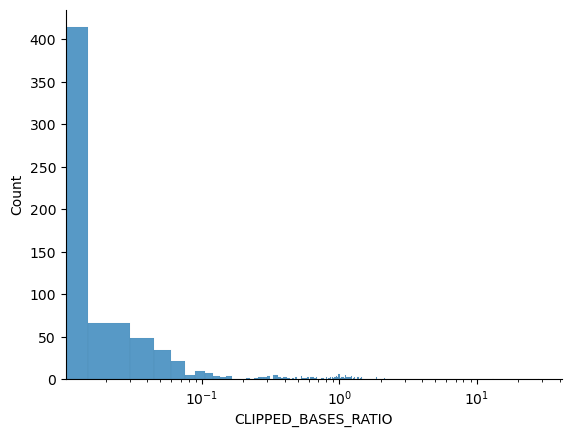

In [265]:
sns.histplot(data=df_candidate_SNPs_ground_truth,
             x='CLIPPED_BASES_RATIO'
            )

plt.xscale('log')
sns.despine()

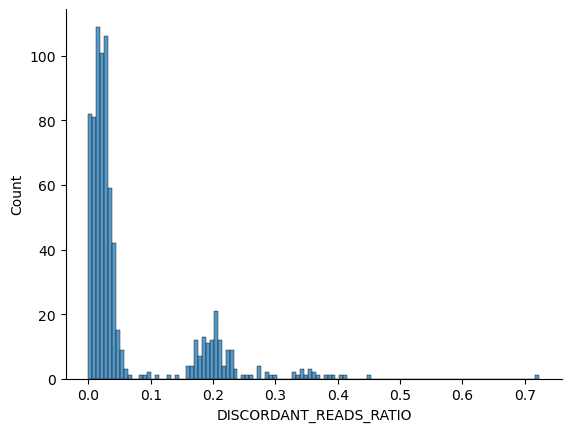

In [267]:
sns.histplot(data=df_candidate_SNPs_ground_truth,
             x='DISCORDANT_READS_RATIO'
            )

# plt.xscale('log')
sns.despine()

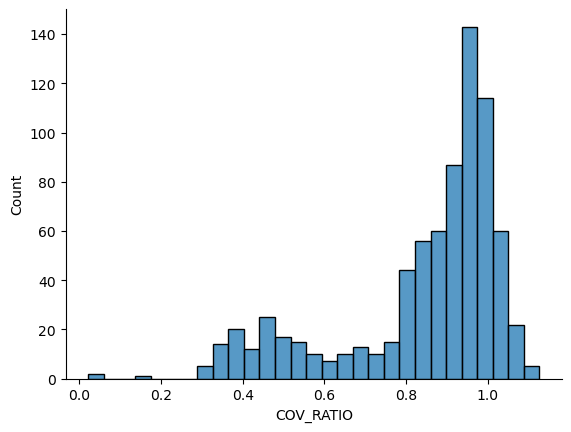

In [270]:
sns.histplot(data=df_candidate_SNPs_ground_truth,
             x='COV_RATIO'
            )

# plt.xscale('log')
sns.despine()

In [262]:
df_candidate_SNPs_ground_truth[predictors]

,COV_RATIO,CLIPPED_BASES_RATIO,DISCORDANT_READS_RATIO,Mean_BQ_ALT_allele
0,0.967228,0.003663,0.018315,35.238095
1,0.956306,0.008224,0.230263,34.855634
2,0.893218,0.001887,0.220755,35.911439
3,0.424088,1.071429,0.028571,34.280702
4,0.428292,1.071429,0.028571,34.600000
...,...,...,...,...
763,0.991011,0.002817,0.028169,36.608696
764,0.938154,0.000000,0.201342,36.274262
765,0.928845,0.003650,0.189781,36.225589
766,0.810045,0.125000,0.006250,36.883721


In [239]:
sample = 'MFS-10'
df_test = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/Bayesian_detector/lowAF_SNPs.csv")
print(len(df_test.columns))

31


In [241]:
df_test[['POS', 'REF', 'ALT', 'AF', 'COV_RATIO', 'CLIPPED_BASES_RATIO', 'DISCORDANT_READS_RATIO', 'Mean_BQ_ALT_allele']]

,POS,REF,ALT,AF,COV_RATIO,CLIPPED_BASES_RATIO,DISCORDANT_READS_RATIO,Mean_BQ_ALT_allele


In [225]:
df_ground_truth_single_sample = pd.read_csv(f"{personal_ref_dir}/MFS-1/lowAF_comparison/ground_truth.csv")

In [226]:
df_ground_truth_single_sample

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,2076862,A,G,5.454550e-14,NaN,262,241,21,0.080153,60.0,...,116,125,9,12,3.74013,3.94093,3.1137,19.67030,10.0,11.0
1,4314991,CG,C,4.098460e-14,NaN,320,302,17,0.053125,60.0,...,205,97,9,8,86.87800,3.13803,4.1599,5.88642,7.0,10.0


In [199]:
X_train_mean

array([ 0.84099071, 22.70086957, 26.45565217, 36.10889762])

In [200]:
X_train_sd

array([ 0.20152161, 43.63418185, 41.69004926,  2.25967589])

In [191]:
X_train

array([[0.8718074656188606, 3, 106, 36.03947368421053],
       [0.7958371594735232, 103, 14, 38.85714285714285],
       [0.9288413098236776, 3, 11, 35.02857142857143],
       ...,
       [0.8213932806324111, 3, 72, 36.63768115942029],
       [0.3720514919264827, 71, 0, 33.416666666666664],
       [0.8421761832575374, 4, 7, 35.1520737327189]], dtype=object)

In [180]:
df_candidate_SNPs_ground_truth.loc[pd.isnull(df_candidate_SNPs_ground_truth['COV_RATIO'])][['SampleID', 'POS', 'REF', 'ALT']]

,SampleID,POS,REF,ALT
765,MFS-119,264908,G,A
766,MFS-121,2941828,A,G
767,MFS-129,1860116,G,A
768,MFS-129,2588836,T,C
769,MFS-130,1860116,G,A
770,MFS-130,2588836,T,C
771,MFS-132,1380268,T,C
772,MFS-132,3019985,A,G
773,MFS-132,4134127,G,A
774,MFS-135,3606001,G,A


In [181]:
sample = 'MFS-7'

df_ground_truth = pd.read_csv(f"{ground_truth_directory}/{sample}/lowAF_comparison/ground_truth.csv").query("REF.str.len() == ALT.str.len()")
df_detected = pd.read_csv(f"{lowAF_directory}/{sample}/Bayesian_detector/lowAF_SNPs.csv")

df_excludeLowConf_variants = pd.read_csv(f"{lowAF_directory}/{sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t')

df_excludeLowConf_variants['AF'] = df_excludeLowConf_variants['AO'] / df_excludeLowConf_variants['DP']

In [183]:
df_ground_truth[['POS', 'REF', 'ALT', 'AF']]

,POS,REF,ALT,AF
0,167717,C,T,0.574468
1,1506744,C,G,0.608833
2,2267551,C,T,0.064417
3,2755424,G,A,0.056338
4,2819006,T,C,0.084112


In [184]:
df_detected

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,DPB,RO,AO,...,RPPR,RPL,RPR,AF,Mean_BQ_ALT_allele,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO
0,Chromosome,163705,C,T,9.853660e+03,NaN,340,340.0,0,327,...,0.00000,161.0,166.0,0.961765,36.201835,359,370.90,14,1,0.967916
1,Chromosome,163706,C,T,9.853660e+03,NaN,340,340.0,0,327,...,0.00000,161.0,166.0,0.961765,36.175227,359,370.69,14,1,0.968464
2,Chromosome,167717,T,C,0.000000e+00,NaN,281,281.0,164,117,...,3.85770,64.0,53.0,0.416370,35.706897,301,323.39,1,1,0.930765
3,Chromosome,1506744,G,C,3.688580e-14,NaN,319,319.0,197,122,...,19.77580,55.0,67.0,0.382445,34.698413,338,355.38,1,3,0.951095
4,Chromosome,2267551,C,T,2.609760e-14,NaN,326,326.0,305,21,...,56.89840,9.0,12.0,0.064417,35.700000,354,360.06,1,7,0.983169
5,Chromosome,2591484,G,A,3.944340e+02,NaN,500,500.0,243,257,...,58.78050,111.0,146.0,0.514000,34.564103,608,641.73,4,155,0.947439
6,Chromosome,2592310,G,A,2.189430e+03,NaN,507,507.0,222,285,...,285.69300,109.0,176.0,0.562130,35.878571,546,624.06,3,101,0.874916
7,Chromosome,2755424,G,A,0.000000e+00,NaN,284,284.0,268,16,...,26.63720,7.0,9.0,0.056338,34.000000,299,309.69,0,5,0.965482
8,Chromosome,2819006,T,C,0.000000e+00,NaN,321,321.0,294,27,...,3.03984,20.0,7.0,0.084112,36.720000,332,347.73,1,6,0.954764
9,Chromosome,3851887,A,C,1.134910e+03,NaN,53,53.0,0,47,...,0.00000,5.0,42.0,0.886792,33.578947,85,181.31,83,1,0.468810


In [64]:
# ------------------------------------------------------------------------------------------------------------------------
# Build model using the samples with ground truth information
# ------------------------------------------------------------------------------------------------------------------------
predictors = ["COV_RATIO", "CLIPPED_BASES", "DISCORDANT_READS", "Mean_BQ_ALT_allele"]
scaler = StandardScaler()

# there should not be any NAs in the predictors columns
assert len(df_candidate_SNPs_ground_truth.dropna(subset=predictors)) == len(df_candidate_SNPs_ground_truth)

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR,SampleID,Real
0,2076862,A,G,5.454550e-14,NaN,262,241,21,0.080153,60.0,...,9,12,3.74013,3.94093,3.1137,19.67030,10.0,11.0,MFS-1,1
0,2057120,G,C,0.000000e+00,NaN,299,279,20,0.066890,60.0,...,8,12,3.08035,4.74748,3.0103,3.20488,10.0,10.0,MFS-51,1


In [386]:
df_single_ground_truth = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-51/lowAF_comparison/ground_truth.csv")

In [387]:
df_single_ground_truth

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,2057120,G,C,0,NaN,299,279,20.0,0.06689,60.0,...,141,138,8.0,12.0,3.08035,4.74748,3.0103,3.20488,10.0,10.0


In [388]:
df_trust_patients.query("SampleID in ['MFS-51', 'MFS-52']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,RIF_AUC,INH_AUC,PZA_AUC,EMB_AUC,View,Outlier,predicted_PLI,predicted_Timika_Score,unique_patient,Date_of_Death
601,T0085,85-07,MFS-52,MFS-52_lib47039,NaN,NaN,1.0,269.47,0.99,0.9856,...,24.308,15.676,283.14,15.676,1B,1.0,27.46122,39.07762,317,NaN
602,T0085,85-01,MFS-51,MFS-51_lib47038,NaN,NaN,1.0,291.34,0.99,0.9876,...,24.308,15.676,283.14,15.676,1B,1.0,27.46122,39.07762,317,NaN


In [126]:
# merge the candidate SNPs from Illumina sequencing with the ground truth information from the hybrid assemblies, but only for samples with hybrid assemblies
df_candidate_SNPs_ground_truth = df_candidate_SNPs.query("SampleID in @samples_with_ground_truth").merge(df_ground_truth[['SampleID', 'POS', 'REF', 'ALT', 'Real']], how='outer', on=['POS', 'SampleID'])

# merged outer to keep everything, so anything that didn't have overlap between candidate SNPs and ground truth is not real
df_candidate_SNPs_ground_truth['Real'] = df_candidate_SNPs_ground_truth['Real'].fillna(0).astype(int)

In [37]:
predictors = ["COV_RATIO", "CLIPPED_BASES", "DISCORDANT_READS", "Mean_BQ_ALT_allele"]
scaler = StandardScaler()

# there should not be any NAs in the predictors columns
assert len(df_candidate_SNPs_ground_truth.dropna(subset=predictors)) == len(df_candidate_SNPs_ground_truth)
           
X_scaled = scaler.fit_transform(df_candidate_SNPs_ground_truth[predictors])
X = pd.DataFrame(X_scaled, columns=predictors)
y = df_candidate_SNPs_ground_truth["Real"].values

# Train-test split, stratifying by real or false variants
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

AssertionError: 

In [127]:
redo_samples = df_candidate_SNPs_ground_truth.loc[pd.isnull(df_candidate_SNPs_ground_truth['COV'])].SampleID.unique()

# for sample in redo_samples:
#     try:
#         os.remove(f"{H37Rv_ref_dir}/{sample}/Bayesian_detector/lowAF_SNPs.csv")
#     except:
#         continue
        
print(len(redo_samples))

3


In [128]:
print(redo_samples)




['MFS-135' 'MFS-325' 'MFS-326']


In [371]:
df_candidate_SNPs_ground_truth.loc[pd.isnull(df_candidate_SNPs_ground_truth['COV'])][['POS', 'SampleID', 'Real']]




,POS,SampleID,Real
502,3606002,MFS-135,1
503,4338594,MFS-325,1
504,4338594,MFS-326,1


In [130]:
for sample in redo_samples:
    num_missing = len(set(df_ground_truth.query("SampleID==@sample").POS) - set(df_candidate_SNPs.query("SampleID==@sample").POS))
    
    print(sample, num_missing)

MFS-135 1
MFS-325 1
MFS-326 1


In [380]:
df_personal_assemblies.loc[df_personal_assemblies[0]=='MFS-52'][1].values

array(['/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-52/assembly/MFS-52.fasta'],
      dtype=object)

In [381]:
df_ground_truth.query("SampleID=='MFS-1'")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR,SampleID,Real
0,2076862,A,G,5.454550e-14,NaN,262,241,21.0,0.080153,60.0,...,9.0,12.0,3.74013,3.94093,3.1137,19.67030,10.0,11.0,MFS-1,1
1,4314991,CG,C,4.098460e-14,NaN,320,302,17.0,0.053125,60.0,...,9.0,8.0,86.87800,3.13803,4.1599,5.88642,7.0,10.0,MFS-1,1


In [382]:
df_ground_truth.query("SampleID=='MFS-52'")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR,SampleID,Real


In [193]:
# sample = 'MFS-135'
sample = 'MFS-325'
# search_pos = [3606001, 3606002]
search_pos = [4338594]

variants_file = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.csv")



In [194]:
variants_file.query("POS in @search_pos")[['POS', 'REF', 'ALT', 'AF', 'SAF', 'SAR', 'MQM']]




,POS,REF,ALT,AF,SAF,SAR,MQM
2160,4338594,AGC,TG,0.741433,115.0,123.0,60.0


In [195]:
df_ground_truth.query("SampleID==@sample")



,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR,SampleID,Real
0,13629,A,G,0.000000e+00,NaN,379,290,89.0,0.234828,60.0000,...,55.0,34.0,21.72990,13.77010,3.22989,9.74935,43.0,46.0,MFS-325,1
1,629735,GC,G,2.095000e-13,NaN,258,186,72.0,0.279070,60.0000,...,33.0,39.0,3.05700,4.09604,4.09604,10.90230,39.0,33.0,MFS-325,1
2,852970,C,A,2.082950e-13,NaN,317,225,92.0,0.290221,60.0000,...,66.0,26.0,46.33360,40.77500,33.59970,34.36640,64.0,28.0,MFS-325,1
3,1699255,ACT,C,6.850990e+02,NaN,201,93,108.0,0.537313,60.0000,...,51.0,57.0,127.43800,3.73412,3.73412,38.52440,57.0,51.0,MFS-325,1
4,2109016,T,C,0.000000e+00,NaN,334,233,101.0,0.302395,60.0000,...,43.0,58.0,4.58532,7.84774,12.49170,6.37468,40.0,61.0,MFS-325,1
5,2697452,A,G,1.124650e-13,NaN,363,321,42.0,0.115702,59.8333,...,22.0,20.0,23.47360,3.21711,4.87156,5.99354,18.0,24.0,MFS-325,1
6,2697458,A,C,3.845260e-14,NaN,362,330,32.0,0.088398,60.0000,...,12.0,20.0,16.93400,7.35324,3.01030,7.45853,16.0,16.0,MFS-325,1
7,3017327,T,C,0.000000e+00,NaN,300,282,18.0,0.060000,60.0000,...,10.0,8.0,32.61010,3.49285,3.01030,3.01030,9.0,9.0,MFS-325,1
8,4338594,TG,AG,2.355370e-13,NaN,331,228,69.0,0.208459,60.0000,...,36.0,33.0,9.44853,3.29354,6.81824,19.81060,40.0,29.0,MFS-325,1
9,4338594,TG,AGC,2.355370e-13,NaN,331,228,34.0,0.102719,60.0000,...,18.0,16.0,9.44853,3.26577,4.03217,19.81060,19.0,15.0,MFS-325,1


In [156]:
# df_ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
# confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv").drop_duplicates()
# H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/H37Rv_detected.csv")

# lowAF_variants_bothCoords = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None)
# # df_ground_truth['GeneName'] = df_ground_truth['POS'].map(h37Rv_coords_dict)

In [5]:
sample = 'MFS-1'

# [2591484, 2592310]
bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
ref_genome = "/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/ref_genome/H37Rv_NC_000962.3.fna"

variants_file = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-1/freebayes/MFS-1.excludeLowConf.csv"

ref_genome_file = "/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/ref_genome/H37Rv_NC_000962.3.fna"

# ~/MtbLongitudinalDiversity/lowAF_variant_calling/variantDetector/get_alignment_stats.py -s MFS-1 -b /n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-1/bam/MFS-1.dedup.bam -v /n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-1/freebayes/MFS-1.excludeLowConf.csv


In [6]:
df_ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv").drop_duplicates()
H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/H37Rv_detected.csv")

lowAF_variants_bothCoords = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None)
# df_ground_truth['GeneName'] = df_ground_truth['POS'].map(h37Rv_coords_dict)

In [50]:
df_lowAF_SNPs = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/Bayesian_detector/lowAF_SNPs.csv")

In [52]:
df_lowAF_SNPs[['POS', 'REF', 'ALT', 'AF', 'Mean_BQ_ALT_allele', 'COV_RATIO', 'CLIPPED_BASES', 'DISCORDANT_READS']]

,POS,REF,ALT,AF,Mean_BQ_ALT_allele,COV_RATIO,CLIPPED_BASES,DISCORDANT_READS
0,2076862,A,G,0.080153,35.238095,0.967228,1,5
1,2591484,G,A,0.520833,34.855634,0.956306,5,140
2,2592310,G,A,0.562887,35.911439,0.893218,1,117


In [54]:
df_personal_assemblies[0].values

array(['MFS-1', 'MFS-104', 'MFS-105', 'MFS-106', 'MFS-110', 'MFS-113',
       'MFS-115', 'MFS-116', 'MFS-119', 'MFS-120', 'MFS-121', 'MFS-122',
       'MFS-129', 'MFS-130', 'MFS-132', 'MFS-135', 'MFS-136', 'MFS-150',
       'MFS-151', 'MFS-156', 'MFS-157', 'MFS-158', 'MFS-159', 'MFS-16',
       'MFS-160', 'MFS-161', 'MFS-162', 'MFS-163', 'MFS-17', 'MFS-172',
       'MFS-173', 'MFS-181', 'MFS-184', 'MFS-194', 'MFS-199', 'MFS-2',
       'MFS-22', 'MFS-25', 'MFS-259', 'MFS-26', 'MFS-264', 'MFS-266',
       'MFS-27', 'MFS-277', 'MFS-28', 'MFS-29', 'MFS-3', 'MFS-307',
       'MFS-308', 'MFS-309', 'MFS-310', 'MFS-311', 'MFS-312', 'MFS-313',
       'MFS-314', 'MFS-315', 'MFS-316', 'MFS-317', 'MFS-318', 'MFS-319',
       'MFS-320', 'MFS-321', 'MFS-322', 'MFS-323', 'MFS-324', 'MFS-325',
       'MFS-326', 'MFS-327', 'MFS-328', 'MFS-329', 'MFS-33', 'MFS-330',
       'MFS-34', 'MFS-37', 'MFS-377', 'MFS-38', 'MFS-381', 'MFS-4',
       'MFS-41', 'MFS-42', 'MFS-44', 'MFS-5', 'MFS-51', 'MFS-513',
    

In [ ]:
df_SNPs

```bash
for sample_dir in /n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/*; do
    sample_id=$(basename "$sample_dir")

    python3 ~/MtbLongitudinalDiversity/lowAF_variant_calling/variantDetector/get_alignment_stats.py \
        -s "$sample_id" \
        -b "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/${sample_id}/bam/${sample_id}.dedup.bam" \
        -v "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/${sample_id}/freebayes/${sample_id}.excludeLowConf.csv"
    
    echo "Finished $sample_id"
done
```

In [10]:
df_ground_truth.query("REF.str.len() == ALT.str.len()")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,2076862,A,G,5.454550e-14,NaN,262,241,21.0,0.080153,60.0,...,116,125,9.0,12.0,3.74013,3.94093,3.1137,19.6703,10.0,11.0


In [ ]:
BIN_VERSION="1.9.0"

docker pull google/deepvariant:"${BIN_VERSION}" --platform linux/arm64

docker run \
  google/deepvariant:"${BIN_VERSION}" \
  /opt/deepvariant/bin/run_deepvariant \
  --model_type=WGS \
  --vcf_stats_report=true \
  --ref=H37Rv_NC_000962.3.fna \
  --reads=BAMs/MFS-1.dedup.bam \
  --output_vcf=DeepVariant/VCF/MFS-1.vcf.gz \
  --output_gvcf=DeepVariant/VCF/MFS-1.g.vcf.gz \
  --intermediate_results_dir DeepVariant/intermediate_files \
  --num_shards=8 \
  --platform linux/arm64

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF'

In [63]:
df_variants['High_SNP_Density'] = df_variants['POS'].isin(sites_with_high_SNP_density).astype(int)

# merge in the coverage and soft clipped bases information
df_variants = df_variants.merge(df_depth[['POS', 'COV', 'MAX_ROLLING_AVG_COV']]).merge(df_soft_clips[['POS', 'CLIPPED_BASES']])

In [69]:
df_variants[['POS', 'DP', 'COV']]

,POS,DP,COV
0,2076862,262.0,273
1,2591484,480.0,608
2,2592310,485.0,530


In [76]:
dir_name = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-1/lowAF_comparison"

confusion_matrix = pd.read_csv(f"{dir_name}/confusion_matrix.csv")
ground_truth = pd.read_csv(f"{dir_name}/ground_truth.csv")
H37Rv_detected = pd.read_csv(f"{dir_name}/H37Rv_detected.csv")

In [78]:
H37Rv_detected.query("POS in @df_variants.POS")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
5,2076862,A,G,5.454550e-14,NaN,262,241,21.0,0.080153,60.0000,...,116,125,9.0,12.0,3.74013,3.94093,3.1137,19.6703,10.0,11.0
9,2591484,A,G,6.060740e+02,NaN,480,229,250.0,0.479167,60.0000,...,112,117,83.0,167.0,3.24736,64.29790,13.0512,48.1561,108.0,142.0
10,2592310,A,G,2.112290e+03,NaN,485,212,273.0,0.437113,59.9744,...,105,107,158.0,115.0,3.05127,17.71750,71.8054,278.5000,90.0,183.0


In [83]:
ground_truth#.query("POS in @df_variants.POS")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,2076862,A,G,5.454550e-14,NaN,262,241,21.0,0.080153,60.0,...,116,125,9.0,12.0,3.74013,3.94093,3.1137,19.67030,10.0,11.0
1,4314991,CG,C,4.098460e-14,NaN,320,302,17.0,0.053125,60.0,...,205,97,9.0,8.0,86.87800,3.13803,4.1599,5.88642,7.0,10.0


In [84]:
confusion_matrix#.query("POS in @df_variants.POS")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result
0,2076862.0,A,G,2076862,A,G,TP
1,4314991.0,CG,C,4314991,CG,C,TP
2,NaN,NaN,NaN,2342649,AGGCGTACACAC,A,FP
3,NaN,NaN,NaN,33207,GGC,G,FP
4,NaN,NaN,NaN,410006,C,CGTTGGCGCTGGT,FP
5,NaN,NaN,NaN,472711,TTTGTGGGCC,T,FP
6,NaN,NaN,NaN,1418863,CGGGAGCCA,C,FP
7,NaN,NaN,NaN,2153725,C,CTCATCCCCGTCTCG,FP
8,NaN,NaN,NaN,2358029,TG,T,FP
9,NaN,NaN,NaN,2536628,GA,G,FP


In [75]:
df_personal_assemblies.loc[df_personal_assemblies[0]=='MFS-1'][1].values

array(['/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-1/assembly/MFS-1.fasta'],
      dtype=object)

In [67]:
df_variants.query("COV >= MAX_ROLLING_AVG_COV / 2")

,POS,REF,ALT,QUAL,DP,DPB,RO,AO,AF,AF_freebayes,...,ANN,GENE,EFFECT,HGVS_C,HGVS_P,Mean_BQ_ALT_allele,High_SNP_Density,COV,MAX_ROLLING_AVG_COV,CLIPPED_BASES
0,2076862,A,G,5.454550e-14,262.0,262.0,241.0,21.0,0.080153,0.0,...,['G|missense_variant|MODERATE|gcvB|Rv1832|tran...,gcvB,missense_variant,c.986A>G,p.Lys329Arg,35.238095,0,273,282.25,1
1,2591484,G,A,6.060740e+02,480.0,480.0,229.0,250.0,0.520833,1.0,...,['A|missense_variant|MODERATE|uspC|Rv2318|tran...,uspC,missense_variant,c.967G>A,p.Gly323Ser,34.855634,0,608,635.78,5
2,2592310,G,A,2.112290e+03,485.0,485.0,212.0,273.0,0.562887,1.0,...,['A|synonymous_variant|LOW|Rv2319c|Rv2319c|tra...,Rv2319c,synonymous_variant,c.417C>T,p.Ile139Ile,35.911439,0,530,593.36,1
